The PathMNIST dataset is part of the MedMNIST collection (https://medmnist.com/), which provides preprocessed medical imaging datasets designed for classification tasks. A classification task can either be binary (i.e., classifying tissues as malignant or benign), where the labels are zeros and ones. But in multi-label classification, we have more granularity in the grouping schema. This makes it a slightly more challenging classification task, simply because we usually end up with less data in each class. One solution to such problems is to have more data. However, we know that collecting more data in medical imaging settings is actually challenging and expensive. This is where transfer learning can help us.

The PathMNIST dataset provides already preprocessed medical imaging data consisting of 28×28 images extracted from pathology slides of colorectal cancer. It is intended to support the development of ML/AI models for digital pathology and computer vision-based diagnostics.

### Class Labels Explained

The dataset contains **9 classes** with the following labels:

- **0: adipose**  
  Regions containing fat tissue.

- **1: background**  
  Areas with no tissue, typically representing empty or background space.

- **2: debris**  
  Cellular or non-cellular debris present in the tissue sample.

- **3: lymphocytes**  
  Immune cells involved in the body’s response to tumors.

- **4: mucus**  
  Mucus observed in the sample.

- **5: smooth muscle**  
  Tissue regions composed of smooth muscle cells.

- **6: normal colon mucosa**  
  Healthy colon mucosal tissue.

- **7: cancer-associated stroma**  
  Supportive tissue (stroma) surrounding cancer cells, which may undergo changes in the presence of a tumor.

- **8: colorectal adenocarcinoma epithelium**  
  Epithelial cells derived from colorectal adenocarcinoma, representing cancerous tissue.


What we will do in this session

1.   Load the PathMNIST dataset, perform data inspection, and visualize the images.
2.   Split the dataset into train/val sets for a proper machine learning workflow.
3. Define image transformation (normalization, augmentation)
4. Choose a pre-trained model (EfficientNet model) and modify it for 9-class classification.
5. Fine-tune the model on a smaller dataset of PathMNIST database.
6. We will keep track of training and validation losses and accuracies during training over different epochs. (making sure the model is not over-fitting the training data, and it is able to generalize to a validation set which is a trustworthy represetable of type of test set we are going to deal with in the wild (in industry or academia or any other project that we are going to work on))
7. Compute per-class sensitivity and specificity metrics.




In [3]:
!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

from medmnist import INFO, Evaluator, PathMNIST

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from torchsummary import summary
import time

# Set device
if torch.cuda.is_available():
  device = torch.device('cuda')
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device('cpu')

print(f"Using device {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.6 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256

# Step 2: Load the Dataset

MedMNIST (https://medmnist.com/) provides several preprocessed datasets for medical imaging tasks, including PathMNIST, which consists of pathology slides from colorectal cancer. Each image is 28×28 and belongs to one of 9 classes.


In [5]:
import os

os.makedirs("data", exist_ok=True)

# Preparing the data
data_flag = 'pathmnist'
download = True

# Define data transformations with normalization.
# You can also add basic augmentations such as RandomRotation, RandomHorizontalFlip, etc.
# Data augmentation is one approach to address the data scarcity problem in medical imaging.
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load datasets
train_dataset_full = PathMNIST(root='data', split="train", transform=transform_train, download=download)
test_dataset = PathMNIST(root='data', split='test', transform=transform_val, download=download)

# Dataset information from MedMNIST
info = INFO[data_flag]
n_classes = len(info["label"])
class_names = info["label"]

print(f"Number of classes: {n_classes}")
print(f"Class labels: {class_names}")

# Display dataset sizes
print(f"Full training set size: {len(train_dataset_full)}")
print(f"Test set size: {len(test_dataset)}")


100%|██████████| 206M/206M [00:11<00:00, 17.6MB/s]


Number of classes: 9
Class labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Full training set size: 89996
Test set size: 7180


# Step 3: Data Splitting and Visualization

We will split our training dataset into training and validation sets. In industry, you typically don't have access to the test set before your model goes into production. This means that in real-world applications of developing AI/ML models for medical data, you usually only have access to a training dataset.

You need to find ways to split the training data so that it can serve both for training and validation. The validation set can be used for purposes such as early stopping, checkpoint saving, and estimating how the model might perform on an external production-time test set.

It’s important to ensure that your validation set is representative of the real-world data distribution. Otherwise, any performance estimates you get from it won’t be reliable at production time.

We’ll now split the training data into training and validation sets to monitor overfitting and tune hyperparameters — a very important step. Hyperparameter optimization should always be based on the validation set, not the training set itself. Optimizing on the training set leads to overfitting and poor generalization.

Let’s go ahead with an 80:20 split.


Training set size: 71997
Validatin set size: 17999


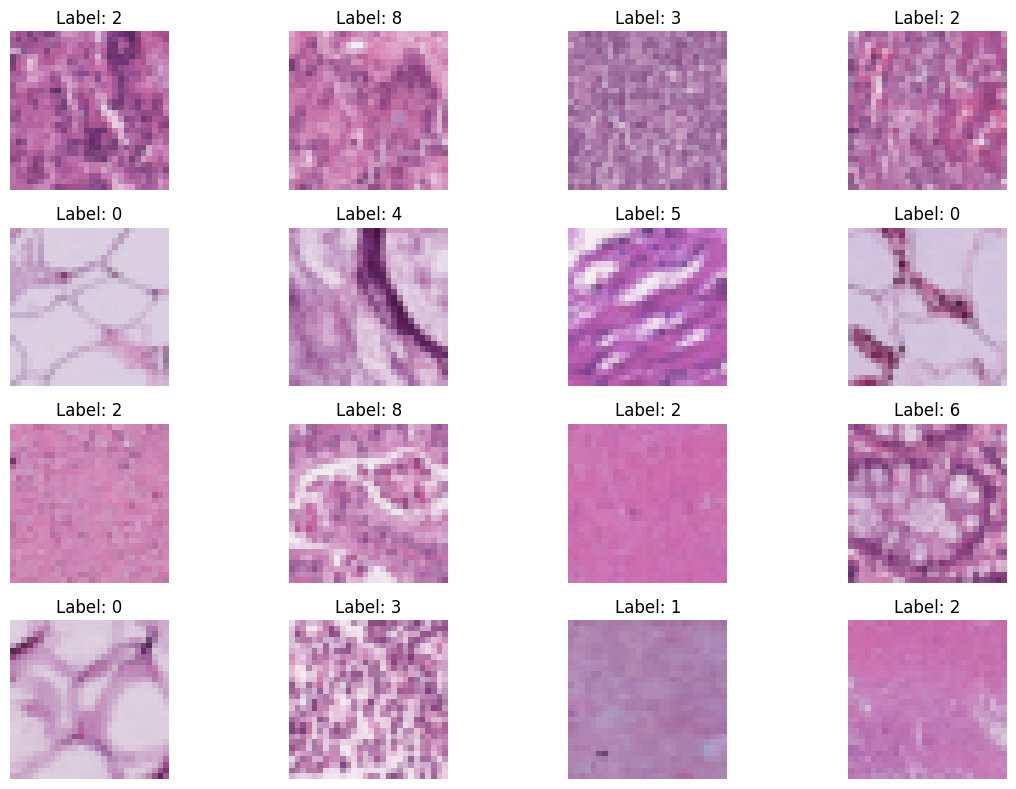

<ipython-input-10-7cc750bfe740>:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_labels = [int(train_dataset_full[i][1]) for i in range(len(train_dataset_full))]


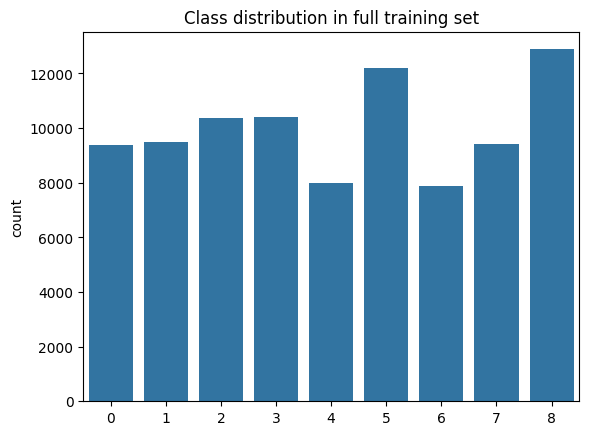

<ipython-input-10-7cc750bfe740>:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  test_labels = [int(test_dataset[i][1]) for i in range(len(test_dataset))]


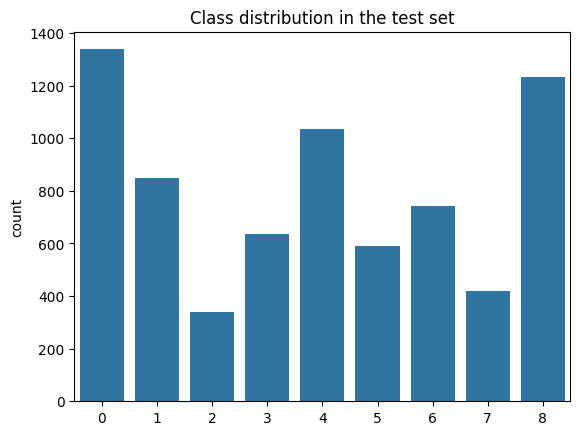

In [10]:
# Split the "train" set into training and validation sets
val_size = int(0.2 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

## Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Visualize a few images
def imshow(img, title=None):
  # Unnormalize the image back to its original scale
  img = img * 0.5 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')

  if title is not None:
    plt.title(title)
  plt.axis('off')

# Get a batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Visualize some sample images with their corresponding labels.
# Refer to the label list provided at the top of the notebook to interpret them.
# Note: The images are low-resolution. This is beneficial for memory usage,
# but makes visual inspection more difficult.
# Fortunately, the dataset is already labeled.
# If this were an unlabeled dataset, it would be very difficult to work with.
# In real-world settings, always advocate for high-quality data and annotations.
# Be sure to communicate clearly with your team—especially those responsible for
# data annotation and data engineering.

plt.figure(figsize=(12, 8))
for i in range(16):
  plt.subplot(4, 4, i + 1)
  imshow(images[i], title=f"Label: {labels[i].item()}")
plt.tight_layout()
plt.show()

# Check class distribution in the full training set
# Convert labels to integers to ensure they are hashable
# If you observe substantial class imbalance—e.g., if a class has less than
# three-quarters the count of the majority class—consider taking specific actions:
# 1. Use stratified splitting.
# 2. Exclude the minority class from analysis if necessary to avoid complications.
# 3. Request more samples for the underrepresented class from your team.
# In any case, ensure everyone on the team is aware of the data imbalance.

all_labels = [int(train_dataset_full[i][1]) for i in range(len(train_dataset_full))]
sns.countplot(x=all_labels)
plt.title("Class distribution in full training set")
plt.show()

test_labels = [int(test_dataset[i][1]) for i in range(len(test_dataset))]
sns.countplot(x=test_labels)
plt.title("Class distribution in the test set")
plt.show()


# Step 4: Load the pre-trained model

In this step, we'll use EfficientNet as our base model.
Other examples, such as AlexNet and GoogleNet, are also covered in the lecture slides.


In [14]:
import torchvision.models as models

# When fine-tuning a pretrained model, set pretrained=True to leverage learned features.
# If you'd like to test performance from a random initialization instead (to assess the
# benefit of pretraining), set pretrained=False.
model = models.efficientnet_b0(pretrained=True)

# Modify the final layer to match the number of classes in our dataset.
# For example, if we have 9 classes, the output layer should return 9 probabilities.
# Likewise, for 119 classes, it should return 119 probabilities.
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, n_classes)

# Move the model to the appropriate device (e.g., GPU via CUDA or AMD, MPS, or CPU)
model = model.to(device)

# torchsummary does not support MPS, so temporarily move the model to CPU for the summary
summary(model.cpu(), (3, 28, 28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             864
       BatchNorm2d-2           [-1, 32, 14, 14]              64
              SiLU-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]             288
       BatchNorm2d-5           [-1, 32, 14, 14]              64
              SiLU-6           [-1, 32, 14, 14]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12           [-1, 32, 14, 14]               0
           Conv2d-13           [-1, 16, 14, 14]             512
      BatchNorm2d-14           [-1, 16,

# Step 5: Define helper functions for fine-tuning


In [16]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer and learning rate
# We're using the Adam optimizer here. It’s also worth experimenting with SGD,
# different learning rates, or even learning rate schedulers (e.g., cosine annealing).
# If your model overfits quickly—i.e., training accuracy rises fast but validation accuracy diverges—
# this might indicate an excessively high learning rate.
# In that case, try lowering the learning rate.
# However, note that in some cases, performance issues stem from limited model capacity,
# and adjusting the learning rate alone may not help.
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Function to calculate classification accuracy
def calculate_accuracy(y_pred, y):
  _, preds = torch.max(y_pred, 1)
  correct = torch.sum(preds == y).item()
  return correct / len(y)

# Training function for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer):
  model.train()
  running_loss = 0.0
  running_acc = 0.0

  for images, labels in dataloader:
    # Move data to the appropriate device
    images, labels = images.to(device), labels.to(device)

    # If labels have an extra dimension, squeeze them to 1D
    if labels.ndim > 1:
      labels = labels.squeeze()

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    running_acc += calculate_accuracy(outputs, labels) * images.size(0)

  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_acc = running_acc / len(dataloader.dataset)
  return epoch_loss, epoch_acc

# Validation function
def validate(model, dataloader, criterion):
  model.eval()
  running_loss = 0.0
  running_acc = 0.0

  with torch.no_grad():
    for images, labels in dataloader:
      images, labels = images.to(device), labels.to(device)

      if labels.ndim > 1:
        labels = labels.squeeze()

      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * images.size(0)
      running_acc += calculate_accuracy(outputs, labels) * images.size(0)

  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_acc = running_acc / len(dataloader.dataset)
  return epoch_loss, epoch_acc


# Step 6: Train (fine-tune) and validate the model


In [18]:
num_epochs = 5

# Lists to store training and validation metrics
train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
  val_loss, val_acc = validate(model, val_loader, criterion)

  # Record metrics for this epoch
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  val_losses.append(val_loss)
  val_accs.append(val_acc)

  print(f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

end_time = time.time()
print(f"Training completed in: {(end_time - start_time) / 60:.2f} minutes")


Epoch [1/5] Train Loss: 0.4070, Train Acc: 0.8573 | Val Loss: 0.2489, Val Acc: 0.9207
Epoch [2/5] Train Loss: 0.3080, Train Acc: 0.8926 | Val Loss: 0.2554, Val Acc: 0.9371
Epoch [3/5] Train Loss: 0.2487, Train Acc: 0.9151 | Val Loss: 0.1724, Val Acc: 0.9455
Epoch [4/5] Train Loss: 0.2074, Train Acc: 0.9279 | Val Loss: 0.1574, Val Acc: 0.9463
Epoch [5/5] Train Loss: 0.1719, Train Acc: 0.9409 | Val Loss: 0.1374, Val Acc: 0.9547
Training completed in: 10.44 minutes


# Step 7: Plot training and validation curves

This step is extremely important. These curves help you assess whether your chosen learning rate and model complexity are appropriate for your task.

They reveal key insights such as:
- How quickly the model is converging
- Whether it's overfitting (e.g., training accuracy high but validation accuracy low)
- If there's underfitting (both accuracies are low)
Use these plots to guide decisions on tuning hyperparameters or adjusting model architecture.


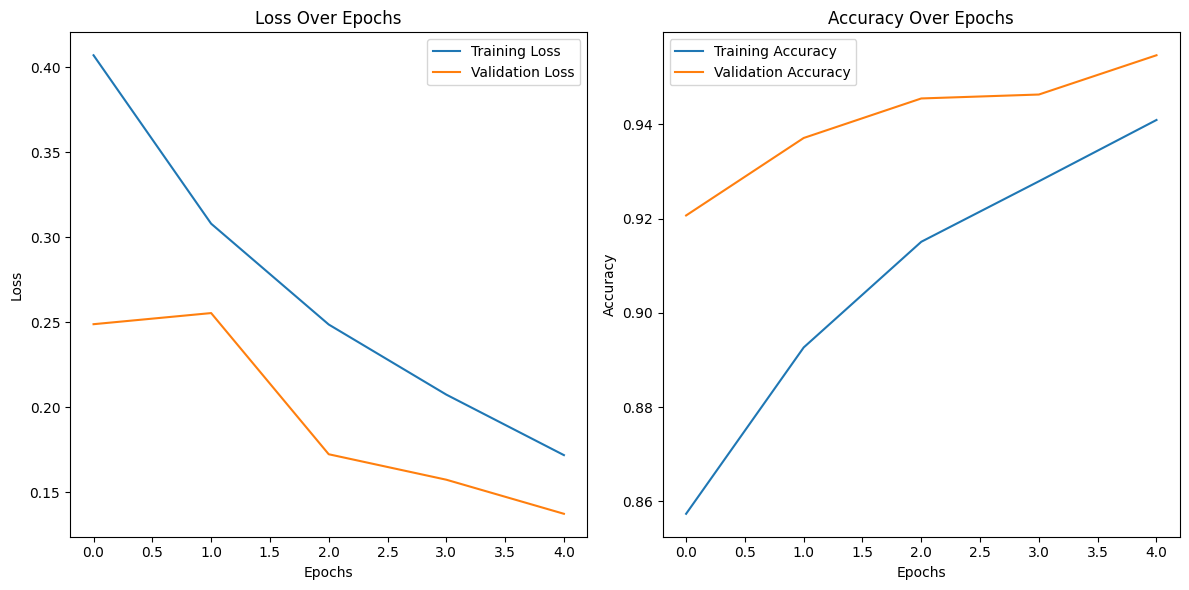

In [19]:
# Plot training and validation loss and accuracy over epochs
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Over Epochs")

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accs, label='Training Accuracy')
plt.plot(range(num_epochs), val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")

plt.tight_layout()
plt.show()


# Step 8: Evaluate on the test set

After training and validation, we now evaluate the model on the hold-out test set

Test accuracy: 0.1296
Classificatin report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1338
           1       0.94      1.00      0.97       847
           2       0.67      0.78      0.72       339
           3       0.91      0.95      0.93       634
           4       0.98      0.88      0.93      1035
           5       0.79      0.62      0.70       592
           6       0.86      0.89      0.87       741
           7       0.62      0.64      0.63       421
           8       0.91      0.90      0.91      1233

    accuracy                           0.88      7180
   macro avg       0.85      0.85      0.85      7180
weighted avg       0.89      0.88      0.88      7180



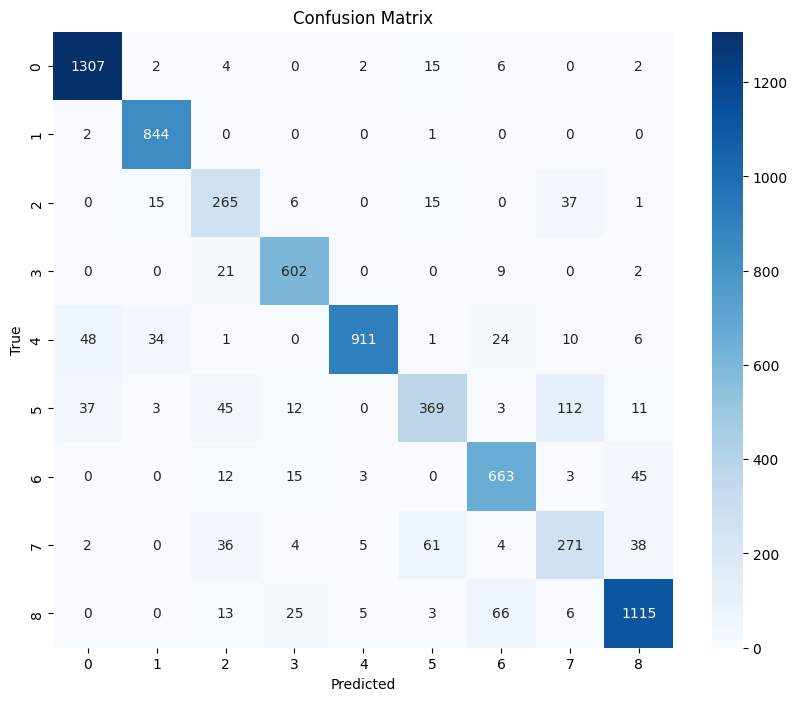

In [20]:
model.eval()

all_labels = []
all_preds = []

# Inference loop for test data (no gradient calculation needed)
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy())
    all_preds.extend(preds.cpu().numpy())

# Convert label and prediction lists to NumPy arrays for metric calculations
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# --- Calculate overall accuracy
acc = np.mean(all_labels == all_preds)
print(f"Test accuracy: {acc:.4f}")

# Display detailed classification metrics (precision, recall, F1-score per class)
print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(i) for i in range(n_classes)],
            yticklabels=[str(i) for i in range(n_classes)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Derive sensitivity and specificity

 Sensitivity (also known as Recall) for class i:
     TP / (TP + FN)

 Specificity for class i:
      TN / (TN + FP)


In [22]:
sensitivities = []
specificities = []

for i in range(n_classes):
  # For class i:
  # True Positives (TP): predicted == i and actual == i
  # False Positives (FP): predicted == i but actual != i
  # False Negatives (FN): predicted != i but actual == i
  # True Negatives (TN): predicted != i and actual != i

  tp = cm[i, i]
  fp = cm[:, i].sum() - tp
  fn = cm[i, :].sum() - tp
  tn = cm.sum() - (tp + fp + fn)

  sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
  specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

  sensitivities.append(sensitivity)
  specificities.append(specificity)

# Create a DataFrame to display sensitivity and specificity per class
df_metrics = pd.DataFrame({
  'Class': [f'Class_{i}' for i in range(n_classes)],
  'Sensitivity': sensitivities,
  'Specificity': specificities
})
print(df_metrics)


     Class  Sensitivity  Specificity
0  Class_0     0.976831     0.984765
1  Class_1     0.996458     0.991473
2  Class_2     0.781711     0.980705
3  Class_3     0.949527     0.990529
4  Class_4     0.880193     0.997559
5  Class_5     0.623311     0.985428
6  Class_6     0.894737     0.982606
7  Class_7     0.643705     0.975144
8  Class_8     0.904298     0.982344
